In [1]:
import numpy as np
import pickle as pkl   
import matplotlib.pyplot as plt
import matplotlib.image as image
import matplotlib.lines as mlines
import matplotlib.patheffects as PathEffects
from utils import plot_adjacency_matrix, plot_level, plot_path


In [2]:
# Load the data about the levels in the game
levels = pkl.load(open('data/LevelsFinal.pkl','rb'))

### Figure 1 - Game Screenshots and one example level for each category

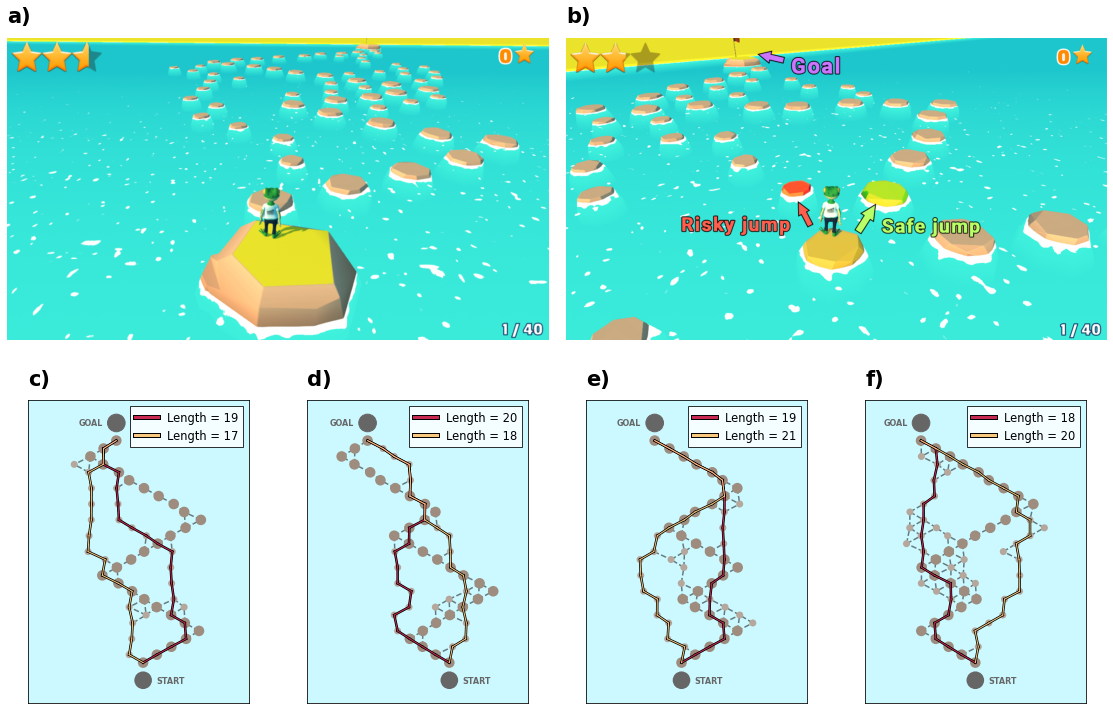

In [3]:
color_bordeaux = np.array([199, 41, 83])/255
color_yellow_sunset = np.array([247, 200, 125])/255

# Figura che metta assieme tutti i plot precedenti
fig = plt.figure(figsize=(20,12), dpi=72)
gs = fig.add_gridspec(2,4, width_ratios=(0.25,0.25,0.25,0.25), wspace=0)

ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])
ax3 = fig.add_subplot(gs[1, 2])
ax4 = fig.add_subplot(gs[1, 3])
ax5 = fig.add_subplot(gs[0, 0:2])
ax6 = fig.add_subplot(gs[0, 2:4])
axes = [ax5, ax6, ax1, ax2, ax3, ax4]

# Screenshot 1
game_image = image.imread('assets/GameScreenshot.png')
plt.sca(axes[1])
plt.imshow(game_image)

ax_img = axes[1]
ax_img.spines.top.set_visible(False)
ax_img.spines.bottom.set_visible(False)
ax_img.spines.left.set_visible(False)
ax_img.spines.right.set_visible(False)
ax_img.set(xticks=[], yticks=[])

# Screenshot 2
game_image = image.imread('assets/PreplanningScreenshot.png')
plt.sca(axes[0])
plt.imshow(game_image)

ax_img = axes[0]
ax_img.spines.top.set_visible(False)
ax_img.spines.bottom.set_visible(False)
ax_img.spines.left.set_visible(False)
ax_img.spines.right.set_visible(False)
ax_img.set(xticks=[], yticks=[])

for i,l in enumerate(['a','b','c','d','e','f']):
    axes[i].text(0, 1.05, f'{l})', transform=axes[i].transAxes, size=21, weight='bold')

# One top-down level view for each combination of the two factors
level_type = ['SS','SL','LS','LL']
level_inds = [0,1,14,15]
text_shifts = [(-5,5), (3,-5), (-4,4), (4, -4)]
text_ha = [('right','left'), ('left','right'), ('right','left'), ('left','right')]

for i, ind in enumerate(level_inds):

    plt.sca(axes[i+2])
    level = levels[ind]

    plot_adjacency_matrix(level, alpha=0.5)
    plot_level(level, show_text=True)

    d = level.decision_points[0]
    plot_path(level, [0, *d.paths[0]], col=color_bordeaux)
    plot_path(level, [0, *d.paths[1]], col=color_yellow_sunset)

    leg_path_0 = mlines.Line2D([], [], linewidth=3, color=color_bordeaux, label=f'Length = {len(d.paths[0])}')
    leg_path_1 = mlines.Line2D([], [], linewidth=3, color=color_yellow_sunset, label=f'Length = {len(d.paths[1])}')
    leg_path_0.set_path_effects([PathEffects.withStroke(linewidth=5, foreground='k')])
    leg_path_1.set_path_effects([PathEffects.withStroke(linewidth=5, foreground='k')])

    plt.legend(handles = [leg_path_0, leg_path_1], loc='upper right', fontsize=11.5, fancybox=False, edgecolor='k')
